# Per-house / allegiance-group TF-IDF word clouds

For each of the **top-12 largest allegiance groups** (by inferred member count), build one document by concatenating every member's biography and attributed quotes, run TF-IDF across the 12 documents, and render a word cloud per group. The groups include noble houses as well as institutions and factions such as the Citadel, Night's Watch, Faith of the Seven, and Mance Rayder's wildling faction.

House/faction labels use the §2.5 inference logic from `community_vs_region.ipynb` (Layer 0: walk the full allegiance list; Layer 1: single-hop family fallback) - **re-implemented inline, no CSV writes**.


In [25]:
import math
import string
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

## 1. Load data and re-implement the §2.5 house inference

Same Layer 0 + Layer 1 logic as in `community_vs_region.ipynb` - kept inline so this notebook is self-contained and the persisted CSVs are untouched.

In [26]:
df = pd.read_csv('../csvs/characters_enriched_v3.csv').fillna('')
bios_df = pd.read_csv('../csvs/characters_bio.csv').fillna('')
bios = dict(zip(bios_df['ID'], bios_df['bio']))

# Load quotes from characters_quotes.csv (one row per quote: name, ID, quote, speaker_id, recipient_id).
# Aggregate by speaker_id - every quote is attributed to whoever spoke it, regardless of which
# character's page it was scraped from.
import os
if os.path.exists('../csvs/characters_quotes.csv'):
    quotes_df = pd.read_csv('../csvs/characters_quotes.csv').fillna('')
    quotes_df = quotes_df[quotes_df['speaker_id'].str.len() > 0]
    quotes = quotes_df.groupby('speaker_id')['quote'].apply(lambda s: ' '.join(s)).to_dict()
    print(f'Loaded {len(quotes_df)} quotes attributed to {len(quotes)} distinct speakers')
else:
    quotes = {}
    print('characters_quotes.csv not found - running on bios only')

# Character-name filter: every token that appears in any character's display name
character_name_tokens = set()
for nm in df['name']:
    for part in str(nm).lower().split():
        cleaned = part.strip(string.punctuation)
        if cleaned and cleaned.isalpha() and len(cleaned) > 2:
            character_name_tokens.add(cleaned)
print(f'Character-name filter: {len(character_name_tokens)} tokens (e.g. {list(character_name_tokens)[:8]})')

REGION_TO_HOUSES = {
    'North': ['House_Stark', 'House_Bolton', 'House_Karstark', 'House_Manderly', 'House_Umber',
              'House_Mormont', 'House_Glover', 'House_Reed', 'House_Ryswell', 'House_Dustin',
              'House_Cerwyn', 'House_Hornwood', 'House_Tallhart', 'House_Flint', 'House_Cassel',
              'House_Ashwood', 'House_Locke', 'House_Magnar', 'House_Forrester', 'House_Stout',
              'House_Slate', 'House_Norrey', 'House_Wull', 'House_Liddle', 'House_Burley',
              'House_Harclay', 'House_Knott'],
    'Iron_Islands': ['House_Greyjoy', 'House_Harlaw', 'House_Drumm', 'House_Goodbrother',
                     'House_Saltcliffe', 'House_Stonehouse', 'House_Botley', 'House_Sparr',
                     'House_Wynch', 'House_Codd', 'House_Blacktyde', 'House_Sunderly',
                     'House_Tawney', 'House_Volmark', 'House_Merlyn', 'House_Ironmaker',
                     'House_Farwynd', 'House_Hoare'],
    'Riverlands': ['House_Tully', 'House_Frey', 'House_Bracken', 'House_Blackwood', 'House_Mallister',
                   'House_Mooton', 'House_Vance', 'House_Whent', 'House_Piper', 'House_Darry',
                   'House_Lothston', 'House_Charlton', 'House_Cox', 'House_Erenford', 'House_Goodbrook',
                   'House_Haigh', 'House_Lychester', 'House_Mudd', 'House_Ryger', 'House_Smallwood',
                   'House_Strong', 'House_Terrick', 'House_Paege', 'House_Roote', 'House_Shawney',
                   'House_Wode', 'House_Nayland'],
    'Vale': ['House_Arryn', 'House_Royce', 'House_Corbray', 'House_Waynwood', 'House_Hunter',
             'House_Templeton', 'House_Redfort', 'House_Belmore', 'House_Coldwater', 'House_Egen',
             'House_Grafton', 'House_Hardyng', 'House_Hersy', 'House_Lipps', 'House_Lynderly',
             'House_Melcolm', 'House_Pryor', 'House_Sunderland', 'House_Tollett', 'House_Upcliff',
             'House_Borrell', 'House_Baelish', 'House_Shett', 'House_Crayne'],
    'Westerlands': ['House_Lannister', 'House_Marbrand', 'House_Crakehall', 'House_Lefford', 'House_Brax',
                    'House_Banefort', 'House_Reyne', 'House_Tarbeck', 'House_Westerling', 'House_Spicer',
                    'House_Payne', 'House_Clegane', 'House_Algood', 'House_Bettley', 'House_Broom',
                    'House_Doggett', 'House_Estren', 'House_Falwell', 'House_Farman', 'House_Foote',
                    'House_Garner', 'House_Hetherspoon', 'House_Jast', 'House_Kyndall', 'House_Lannett',
                    'House_Lannister_of_Lannisport', 'House_Lorch', 'House_Lydden', 'House_Moreland',
                    'House_Myatt', 'House_Parren', 'House_Peckledon', 'House_Plumm', 'House_Prester',
                    'House_Ruttiger', 'House_Sarsfield', 'House_Serrett', 'House_Stackspear',
                    'House_Swyft', 'House_Turnberry', 'House_Vikary', 'House_Yew', 'House_Drox',
                    'House_Greenfield', 'House_Sarwyck'],
    'Reach': ['House_Tyrell', 'House_Hightower', 'House_Tarly', 'House_Florent', 'House_Rowan',
              'House_Redwyne', 'House_Oakheart', 'House_Fossoway', 'House_Ambrose', 'House_Chester',
              'House_Costayne', 'House_Beesbury', 'House_Caswell', 'House_Crane', 'House_Cuy',
              'House_Footly', 'House_Gardener', 'House_Graceford', 'House_Grimm', 'House_Hewett',
              'House_Inchfield', 'House_Kidwell', 'House_Leygood', 'House_Lowther', 'House_Lyberr',
              'House_Meadows', 'House_Merryweather', 'House_Mullendore', 'House_Norcross',
              'House_Norridge', 'House_Oldflowers', 'House_Orme', 'House_Osgrey', 'House_Peake',
              'House_Pommingham', 'House_Redding', 'House_Risley', 'House_Roxton', 'House_Serry',
              'House_Shermer', 'House_Sloane', 'House_Stackhouse', 'House_Uffering', 'House_Varner',
              'House_Vyrwel', 'House_Webber', 'House_Westbrook', 'House_Willum', 'House_Wythers',
              'House_Yelshire'],
    'Stormlands': ['House_Baratheon', 'House_Errol', 'House_Estermont', 'House_Penrose', 'House_Tarth',
                   'House_Connington', 'House_Caron', 'House_Dondarrion', 'House_Selmy', 'House_Swann',
                   'House_Wylde', 'House_Bolling', 'House_Buckler', 'House_Cafferen', 'House_Carter',
                   'House_Fell', 'House_Grandison', 'House_Hasty', 'House_Herston', 'House_Horpe',
                   'House_Kellington', 'House_Lonmouth', 'House_Mertyns', 'House_Morrigen', 'House_Musgood',
                   'House_Peasebury', 'House_Rogers', 'House_Seaworth', 'House_Staedmon', 'House_Trant',
                   'House_Wagstaff', 'House_Wensington', 'House_Whitehead', 'House_Toyne'],
    'Dorne': ['House_Martell', 'House_Yronwood', 'House_Dayne', 'House_Allyrion', 'House_Blackmont',
              'House_Fowler', 'House_Gargalen', 'House_Jordayne', 'House_Manwoody', 'House_Qorgyle',
              'House_Santagar', 'House_Toland', 'House_Uller', 'House_Vaith', 'House_Wyl', 'House_Briar',
              'House_Brook', 'House_Brownhill', 'House_Dalt', 'House_Drinkwater', 'House_Holt',
              'House_Hull', 'House_Lake', 'House_Ladybright', 'House_Sand', 'House_Shell', 'House_Wells'],
    'Crownlands': ['House_Targaryen', 'House_Velaryon', 'House_Celtigar', 'House_Massey', 'House_Rosby',
                   'House_Stokeworth', 'House_Buckwell', 'House_Crabb', 'House_Bar_Emmon', 'House_Brune',
                   'House_Byrch', 'House_Chyttering', 'House_Cressey', 'House_Darklyn', 'House_Edgerton',
                   'House_Farring', 'House_Gaunt', 'House_Hayford', 'House_Hogg', 'House_Langward',
                   'House_Longwaters', 'House_Mallery', 'House_Pyle', 'House_Rambton', 'House_Rollingford',
                   'House_Slynt', 'House_Staunton', 'House_Sunglass', 'House_Thorne', 'House_Wendwater',
                   'House_Blackfyre', 'Blacks', 'House_Baratheon_of_Dragonstone',
                   "House_Baratheon_of_King's_Landing"],
    'Beyond_the_Wall': ['Mance_Rayder', 'Stone_Crows', 'Free_Folk', 'Thenn', 'Frozen_Shore', 'Hornfoot_clan'],
    'Essos': ['Drogo', 'Faceless_Men', 'House_of_Loraq', 'Unsullied', 'House_Rogare', 'Volantis',
              'Lys', 'Pentos', 'Braavos', 'Sons_of_the_Harpy', 'Yunkai', 'Astapor', 'Meereen'],
    'Order': ['Citadel', "Night's_Watch", 'Faith_of_the_Seven', 'Kingsguard', 'Maesters', 'Sworn_Brothers'],
    'Sellsword': ['Golden_Company', 'Windblown', 'Second_Sons', 'Brave_Companions', 'Stormcrows',
                  'Company_of_the_Cat', 'Long_Lances', "Maiden's_Men"],
    'Outlaw': ['Brotherhood_without_banners', "Smiling_Knight's_band"],
}
HOUSE_TO_REGION = {h: region for region, hs in REGION_TO_HOUSES.items() for h in hs}

allegiance_lookup = dict(zip(df['ID'], df['allegiance']))
father_lookup     = dict(zip(df['ID'], df['father']))
mother_lookup     = dict(zip(df['ID'], df['mother']))
spouse_lookup     = dict(zip(df['ID'], df['spouse']))


def best_allegiance(allegiance_str):
    """Layer 0 - first listed allegiance that maps to a region wins."""
    if not allegiance_str:
        return ''
    for h in (a.strip() for a in allegiance_str.split(';')):
        if h in HOUSE_TO_REGION:
            return h
    return allegiance_str.split(';')[0].strip()


primary_house = {cid: best_allegiance(allegiance_lookup.get(cid, '')) for cid in df['ID']}

# Layer 1: family fallback (single-hop, father > mother > spouse)
def first_kin_house(cid):
    for col_lookup in [father_lookup, mother_lookup, spouse_lookup]:
        kin_str = col_lookup.get(cid, '')
        if not kin_str:
            continue
        for kin_id in kin_str.split(';'):
            kin_h = primary_house.get(kin_id.strip(), '')
            if kin_h in HOUSE_TO_REGION:
                return kin_h
    return ''

for cid in df['ID']:
    if primary_house.get(cid, '') not in HOUSE_TO_REGION:
        kin_h = first_kin_house(cid)
        if kin_h:
            primary_house[cid] = kin_h

mappable = sum(1 for h in primary_house.values() if h in HOUSE_TO_REGION)
print(f'Characters with a mappable house: {mappable}/{len(primary_house)}')

Loaded 4275 quotes attributed to 505 distinct speakers
Character-name filter: 3033 tokens (e.g. ['redback', 'weeper', 'ill', 'arson', 'antario', 'arrec', 'gillam', 'left'])
Characters with a mappable house: 2730/3690


## 2. Pick the top-12 houses / allegiance groups

Rank by inferred member count (Layer 0 + Layer 1).


In [27]:
house_counts = Counter(
    h for h in primary_house.values() if h in HOUSE_TO_REGION
)
top12_houses = [h for h, _ in house_counts.most_common(12)]
print('Top-12 houses by member count:')
for h, k in house_counts.most_common(12):
    print(f'  {k:>4}  {h}')

Top-12 houses by member count:
   158  Citadel
   146  House_Targaryen
   127  Night's_Watch
   117  House_Frey
   112  House_Stark
    78  Faith_of_the_Seven
    74  House_Lannister
    70  House_Greyjoy
    56  House_Tyrell
    54  Mance_Rayder
    51  House_Hightower
    50  House_Martell


### Interpreting the selected groups

The largest groups are not all noble houses. The top-12 includes institutions and factions such as the Citadel, Night's Watch, Faith of the Seven, and Mance Rayder's wildling faction. We keep them because they behave like allegiance communities in the data, but this means the word clouds should be read as **house / faction vocabularies** rather than strictly noble-house vocabularies.

## 3. Build per-house / faction corpus and tokenize

Same tokenization as `Assignment2.ipynb`: lowercase, NLTK `word_tokenize`, drop English stopwords + punctuation. We additionally drop non-alphabetic tokens because bios and quotes contain dates, numerals, and single-letter remnants from punctuation. Character-name tokens are also filtered so the clouds emphasize topical vocabulary rather than simply repeating the names of prominent characters.


In [28]:
from nltk.collocations import BigramCollocationFinder, BigramAssocMeasures
from nltk.tokenize import MWETokenizer


def base_tokenize(text):
    """Lowercase + word_tokenize + filter stopwords/punct/non-alpha/character-names."""
    return [w for w in word_tokenize(text.lower())
            if w not in stop_words
            and w not in string.punctuation
            and w.isalpha()
            and w not in character_name_tokens]


# Discover collocations on the whole AWOIAF corpus (bio + quotes for every character).
# Mirrors course week 7: contingency-table + chi-squared scoring, then MWETokenizer
# merges significant bigrams into single tokens for the TF-IDF stage.
all_tokens = []
for cid in df['ID']:
    text = bios.get(cid, '') + ' ' + quotes.get(cid, '')
    if text.strip():
        all_tokens.extend(base_tokenize(text))

bigram_measures = BigramAssocMeasures()
finder = BigramCollocationFinder.from_words(all_tokens)
finder.apply_freq_filter(30)  # at least 30 occurrences
collocations = finder.nbest(bigram_measures.chi_sq, 100)
print(f'Found {len(collocations)} significant bigrams. Top 15:')
for w1, w2 in collocations[:15]:
    print(f'  {w1}_{w2}')

mwe = MWETokenizer(collocations, separator='_')


def tokenize(text):
    """base_tokenize + MWETokenizer to merge significant bigrams into single tokens."""
    return mwe.tokenize(base_tokenize(text))


house_tokens = {h: [] for h in top12_houses}
for cid, house in primary_house.items():
    if house in house_tokens:
        text = bios.get(cid, '') + ' ' + quotes.get(cid, '')
        if text.strip():
            house_tokens[house].extend(tokenize(text))

for house in top12_houses:
    print(f'  {house:30s} {len(house_tokens[house]):>6} tokens')


Found 100 significant bigrams. Top 15:
  television_adaptation
  moat_cailin
  game_thrones
  casterly_rock
  vaes_dothrak
  deepwood_motte
  seastone_chair
  adaptation_game
  whispering_wood
  thrones_portrayed
  stony_shore
  haunted_forest
  valyrian_steel
  iron_throne
  brotherhood_banners
  Citadel                          8518 tokens
  House_Targaryen                 22282 tokens
  Night's_Watch                    8928 tokens
  House_Frey                       6372 tokens
  House_Stark                     23398 tokens
  Faith_of_the_Seven               5042 tokens
  House_Lannister                 19320 tokens
  House_Greyjoy                    8644 tokens
  House_Tyrell                     3569 tokens
  Mance_Rayder                     3733 tokens
  House_Hightower                  2557 tokens
  House_Martell                    6390 tokens


### Interpreting the bigrams

The bigram step captures meaningful ASOIAF phrases such as `iron_throne`, `casterly_rock`, `moat_cailin`, and `valyrian_steel`, which would be weaker if split into separate words. It also reveals some page-structure or adaptation leakage, such as phrases related to television adaptation and portrayal. We keep the method because the main signal is useful and course-aligned, but this is a known limitation of scraping broad wiki page text rather than only manually curated in-universe prose.

## 4. Compute TF, IDF, and TF-IDF

**TF (term frequency)** counts how often a word appears in one group's corpus, normalised by document length. **IDF (inverse document frequency)** is `log(N / df)` where `N = 12` selected groups and `df` is the number of groups containing the word. A word common to all 12 selected groups gets IDF = 0, while a word unique to one group gets the highest IDF. **TF-IDF** is the product: it rewards words that are frequent within one group *and* rare across the other selected groups.

IDF helps downweight many generic ASOIAF terms when they appear across most of the selected groups. We still use preprocessing - English stopwords, punctuation filtering, non-alphabetic filtering, and character-name filtering - because some high-frequency wiki or name tokens would otherwise dominate the clouds.


In [29]:
# TF: term frequency normalized by document length
tf_house = {}
for house, tokens in house_tokens.items():
    if not tokens:
        tf_house[house] = {}
        continue
    counts = Counter(tokens)
    total = len(tokens)
    tf_house[house] = {w: c / total for w, c in counts.items()}

# IDF: log(N / docs containing w), N = number of houses
N = len(house_tokens)
doc_freq = Counter()
for tokens in house_tokens.values():
    for w in set(tokens):
        doc_freq[w] += 1
idf = {w: math.log(N / doc_freq[w]) for w in doc_freq}

# TF-IDF
tfidf_house = {
    house: {w: tf * idf.get(w, 0) for w, tf in tf_vals.items()}
    for house, tf_vals in tf_house.items()
}

# Quick sanity print: top-10 TF-IDF terms for the largest house
biggest = top12_houses[0]
top10 = sorted(tfidf_house[biggest].items(), key=lambda x: x[1], reverse=True)[:10]
print(f'Top-10 TF-IDF terms for {biggest}:')
for w, s in top10:
    print(f'  {s:.5f}  {w}')

Top-10 TF-IDF terms for Citadel:
  0.00765  archmaester_citadel
  0.00532  archmaester
  0.00379  author
  0.00294  link
  0.00272  citadel
  0.00219  wrote
  0.00168  conclave
  0.00168  sphinx
  0.00167  book
  0.00147  links


**Reading the Citadel top-10.** `archmaester`, `conclave`, `ravenry`, `sphinx` are clearly Citadel-distinctive vocabulary: the order of maesters and its institutions. Terms such as `author`, `link`, `wrote`, `book`, and `links` are more ambiguous. They could partly come from wiki citation/source sections, but they are also plausible Citadel vocabulary because the Citadel is a scholarly institution built around books, records, authorship, ravens, and learned correspondence. If these words were only generic wiki boilerplate spread evenly across all pages, IDF should mostly downweight them; their survival in the Citadel top terms suggests they are unusually concentrated in Citadel-associated text. We therefore treat them as a documented ambiguity rather than automatically removing them: the dominant signal appears to be institutional Citadel vocabulary, but stricter section filtering would be needed to separate in-universe scholarly language from wiki-source metadata cleanly.


## 5. Word clouds - one per house / allegiance group

4 × 3 grid, ordered by inferred member count (largest first). Word clouds are visual summaries of the TF-IDF rankings: they are useful for quick interpretation, but exact comparisons should rely on the underlying TF-IDF scores rather than visual word area or layout.


Saved ../website/figures/word_clouds/house_cloud.png


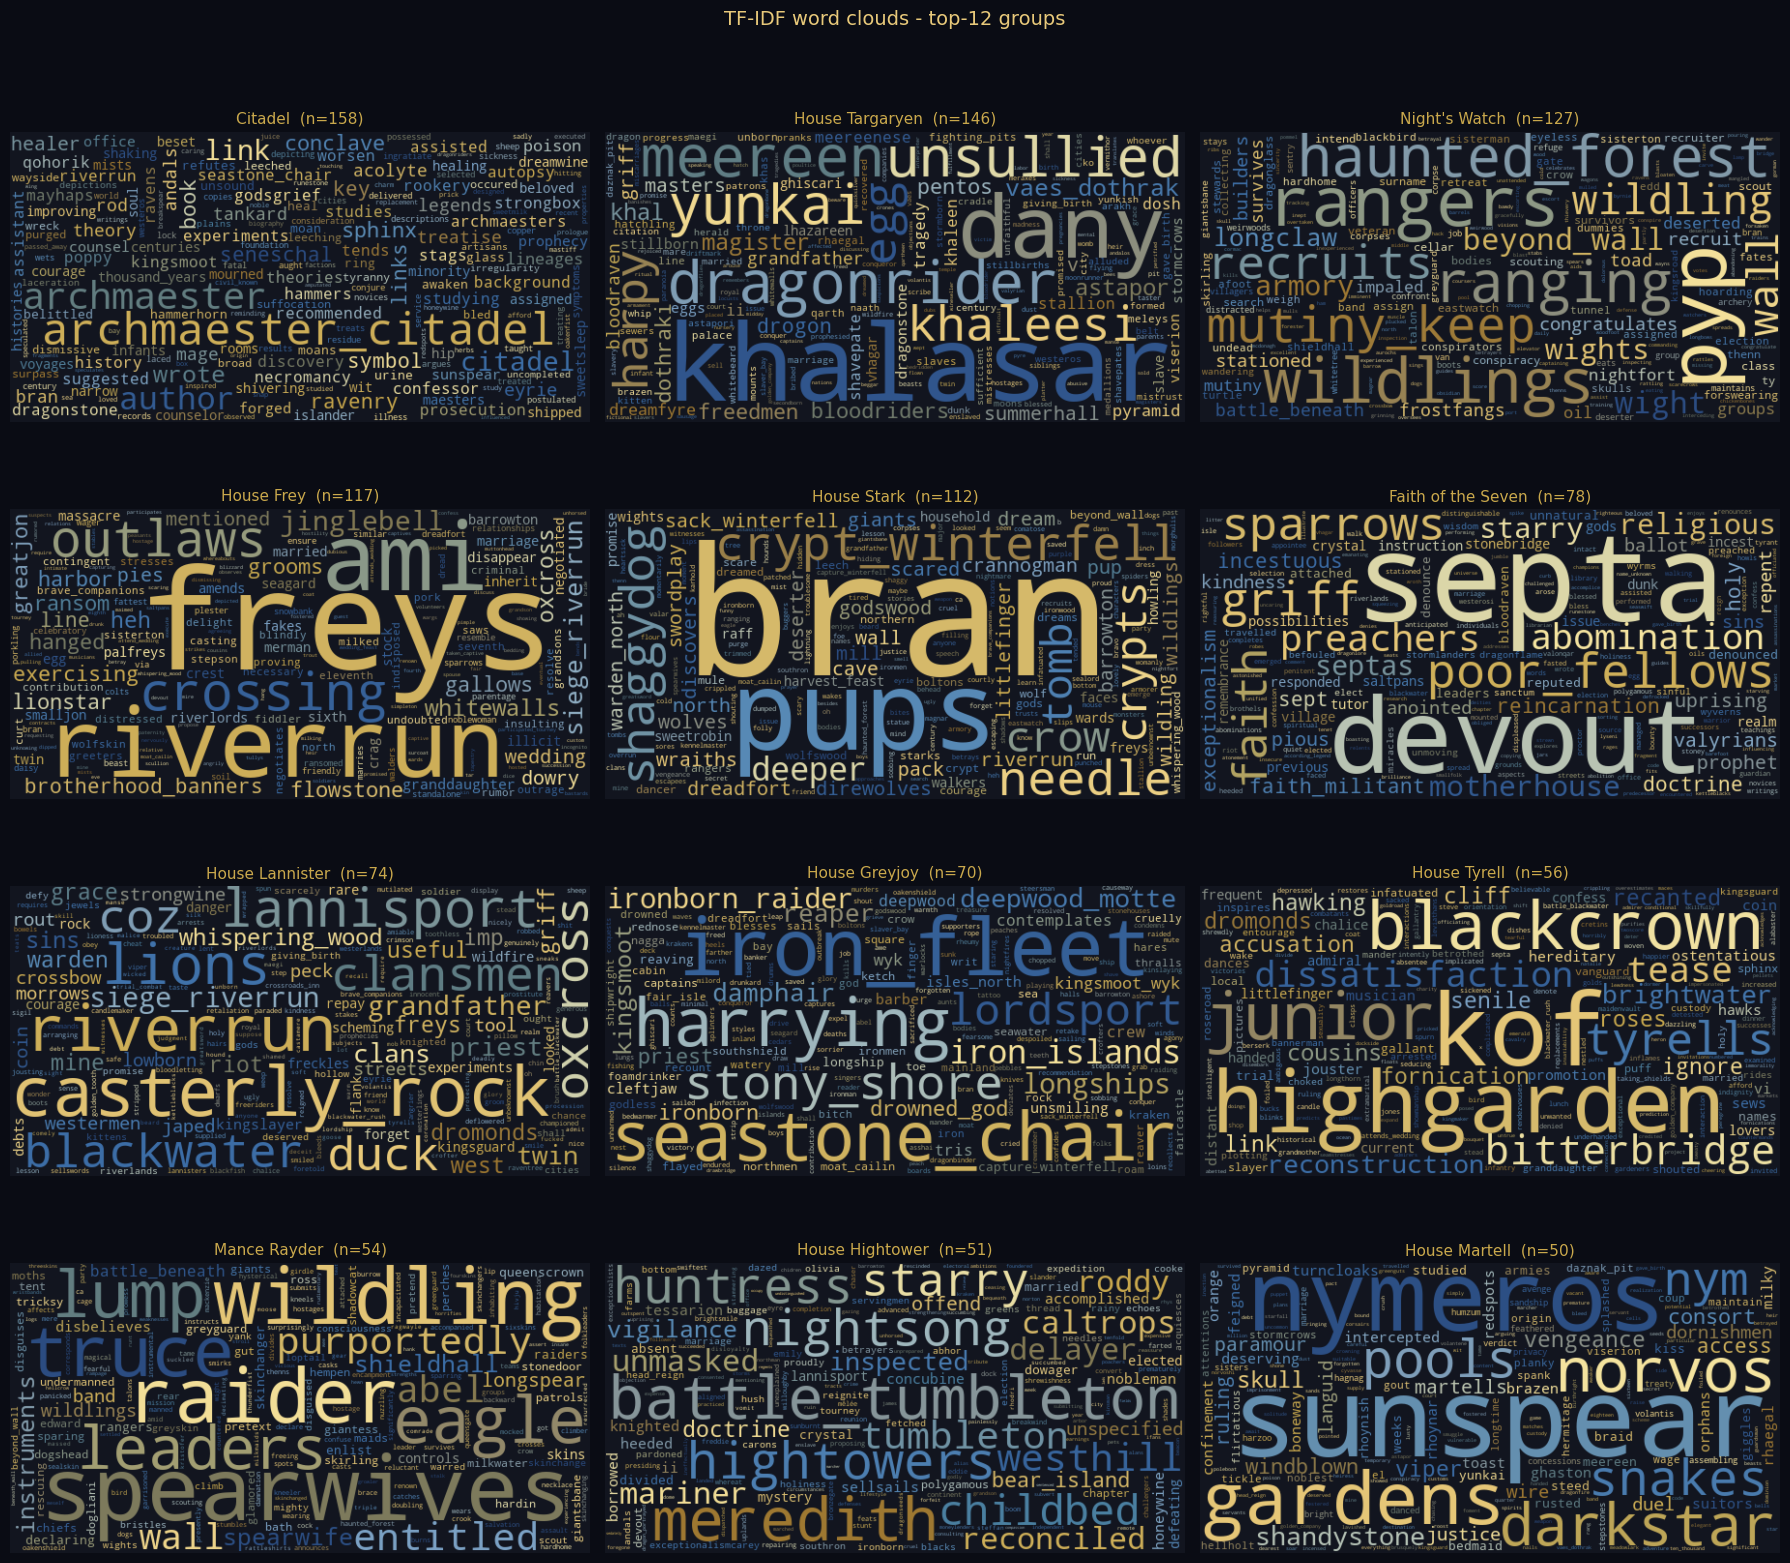

In [ ]:
import random
from matplotlib.colors import LinearSegmentedColormap

karma_colors = [
    "#2A4A7F",   # deep navy blue
    "#3D6FA8",   # medium blue
    "#5B8DB8",   # lighter blue
    "#C9A84C",   # deep gold
    "#D4B86A",   # warm gold
    "#E8C97A",   # bright gold
    "#F5E4A0",   # pale gold
    "#7BA3C8",   # steel blue
    "#A07830",   # dark gold-brown
    "#4A7FA0",   # teal-blue
]
karma_cmap = LinearSegmentedColormap.from_list("karma", karma_colors)

def karma_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    t = random.Random(word).random()
    r, g, b, _ = karma_cmap(t)
    return f"rgb({int(r*255)}, {int(g*255)}, {int(b*255)})"

n_cols = 3
n_rows = math.ceil(len(top12_houses) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
fig.patch.set_facecolor('#0a0c14')
axes_flat = np.atleast_1d(axes).flatten()

for idx, house in enumerate(top12_houses):
    ax = axes_flat[idx]
    ax.set_facecolor('#12151f')
    freqs = tfidf_house.get(house, {})
    if freqs:
        wc = WordCloud(width=600, height=300, background_color='#12151f', color_func=karma_color_func)
        ax.imshow(wc.generate_from_frequencies(freqs), interpolation='bilinear')
    else:
        ax.text(0.5, 0.5, 'No tokens', ha='center', va='center',
                fontsize=12, color='#C9A84C', transform=ax.transAxes)
    ax.axis('off')
    title = f"{house.replace('_', ' ')}  (n={house_counts[house]})"
    ax.set_title(title, fontsize=11, pad=6, color='#C9A84C')

for ax in axes_flat[len(top12_houses):]:
    ax.set_facecolor('#0a0c14')
    ax.axis('off')

plt.suptitle(f'TF-IDF word clouds - top-{len(top12_houses)} allegiances',
             fontsize=14, y=1.01, color='#E8C97A')
plt.tight_layout()

from pathlib import Path
out_path = Path('../website/figures/word_clouds/house_cloud.png')
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
print(f'Saved {out_path}')
plt.show()

**Reading the clouds.** The TF-IDF clouds are visual summaries of the highest-scoring words for each allegiance group; the underlying evidence is the TF-IDF ranking, not the exact visual size of each word. Most groups show canon-plausible lexical fingerprints: Stark terms emphasize northern geography and direwolf imagery, Targaryen terms emphasize dragons, fire, and Valyrian language, Greyjoy terms point toward islands and seafaring, while Night's Watch and Mance Rayder foreground wildling and Wall-related vocabulary.

The Citadel cloud is more ambiguous. It foregrounds clearly institutional terms such as `archmaester`, `conclave`, and `ravenry`, but also book/source terms that may mix in-universe scholarly language with wiki-source metadata. Similar leakage can appear elsewhere because the scraped pages may include adaptation or source-section language. For example, the Lannister cloud includes `duck`, inherited mainly from Tyrion's corpus and Ser Rolly Duckfield's nickname; this is not a Lannister theme in itself, but an overrepresented companion alias from Tyrion's later travel arc. We therefore read the clouds as distinctive lexical signals, not as perfectly clean canon vocabulary.

The main insight is that the text layer adds information the affiliation network cannot show: two houses or factions can occupy similar social or regional positions while being described through very different vocabularies. TF-IDF makes those semantic differences visible.
